In [103]:
#run this everytime an edit is made in utils.py so that we can use the helper functions in this Python Notebook
import importlib
import utils
importlib.reload(utils)

<module 'utils' from '/Users/matthewliew/FINM 375-a/matthew-work/hw-2/utils.py'>

In [ ]:
import pandas as pd
import numpy as np

#Loading in the data
cap_curve = pd.read_excel("cap_curves _2025-06-30.xlsx")
display(cap_curve.head())

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols
0,0.25,0.042353,0.042353,0.989523,NaN,NaN,NaN
1,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842
2,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708
3,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464
4,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341


## 1.1.
Recall that a floor is a portfolio of floorlets which
- depend on the realized interest rate one quarter before the expiration.
- each have the same strike interest rate.

Use Black’s formula to price just one floorlet
- expiring at T=3
- struck at the T=3 swap rate
- notional of 100
- quarterly frequency

In [75]:
strike = cap_curve.loc[cap_curve["tenor"] == 3, "swap rates"].values[0]
price_of_floorlet = utils.price_floorlet(cap_curve, maturity=3, strike=strike)
print(round(price_of_floorlet,6))

0.142948


## 1.2.
- Use Black’s formula to price the entire floor with expiration of T=3.
- The floor has floorlets at quarterly frequency, except the first quarter.

In [76]:
expirations = np.arange(2, 13) / 4
floorlets = []
for exp in expirations:
    floorlets.append(utils.price_floorlet(cap_curve, maturity=exp, strike=strike))

summary = pd.DataFrame({"expirations": expirations, "floorlets": floorlets})
display(summary)
print(f"Price of Cap: {np.array(floorlets).sum()}")

,expirations,floorlets
0,0.50,0.000551
1,0.75,0.021385
2,1.00,0.060129
3,1.25,0.134934
4,1.50,0.156063
5,1.75,0.161993
6,2.00,0.162743
7,2.25,0.171241
8,2.50,0.157445
9,2.75,0.148123


Price of Cap: 1.3175550466703745


## 2.1 Cap Prices
For each cap maturity, .5 < T < 10 use the flat volatility to get the price of the cap.

Report the cap prices across expirations, .5 < T < 10

Plot the cap prices across expirations.

In [106]:
maturities = np.arange(2, 41) / 4
cap_prices = []
flat_vol = []
strike = cap_curve.loc[cap_curve["tenor"] == 10.0, "swap rates"].values[0]

for T in maturities:
    implied_vol = cap_curve.loc[cap_curve["tenor"] == T, "flat vols"].values[0]
    flat_vol.append(implied_vol)
    cap_prices.append(utils.price_cap(cap_curve, T, strike=strike, implied_vol=implied_vol))

prices = pd.DataFrame({"tenor": maturities, "Cap Prices": cap_prices, "Flat Vol": flat_vol})
prices

,tenor,Cap Prices,Flat Vol
0,0.50,0.079089,0.156842
1,0.75,0.127515,0.180709
2,1.00,0.174190,0.204576
3,1.25,0.228484,0.242127
4,1.50,0.292403,0.268642
5,1.75,0.367877,0.285885
6,2.00,0.451693,0.295615
7,2.25,0.529954,0.299596
8,2.50,0.618667,0.299589
9,2.75,0.715456,0.297355


## 2.2 Caplet Prices and Forward Volatilities
Using the cap prices, strip out the

- caplet prices
- forward volatility at tao which properly prices caplet tao using Black’s formula.

List and plot the forward volatility versus the flat volatiltiy.

In [107]:
#Creating a dataframe with all necessary data
full_df = cap_curve.merge(prices, how="inner", on="tenor").drop(columns="Flat Vol")
display(full_df.head())

,tenor,swap rates,spot rates,discounts,forwards,flat vols,fwd vols,Cap Prices
0,0.50,0.040859,0.040852,0.979883,0.039351,0.156842,0.156842,0.079089
1,0.75,0.039391,0.039372,0.971043,0.036414,0.180709,0.201708,0.127515
2,1.00,0.038115,0.038083,0.962807,0.034217,0.204576,0.240464,0.174190
3,1.25,0.036704,0.036653,0.955417,0.030938,0.242127,0.328341,0.228484
4,1.50,0.035655,0.035590,0.948239,0.030280,0.268642,0.336521,0.292403


In [111]:
import numpy as np

#Function to strip caps
def strip_caps(df, strike, delta=0.25, notional=100):
    """
    Strip caplet prices and forward vols from cap prices.

    Parameters
    ----------
    df : DataFrame
        Must contain:
            - "tenor"
            - "Cap Prices"
            - "discounts"
            - "forwards"

    strike : float
        Strike of the caps.

    Returns
    -------
    DataFrame with:
        - caplet_price
        - forward_vol
    """

    df = df.sort_values("tenor").reset_index(drop=True)

    caplet_prices = []
    forward_vols = []

    prev_cap_price = 0.0

    for i in range(len(df)):

        maturity = df.loc[i, "tenor"]
        cap_price = df.loc[i, "Cap Prices"]

        # Step 1: strip caplet price
        caplet_price = cap_price - prev_cap_price
        caplet_prices.append(caplet_price)

        # Step 2: compute implied vol of this caplet
        vol = utils.find_caplet_implied_vol(
            df,
            maturity,
            strike,
            caplet_price,
            delta=delta,
            notional=notional
        )

        forward_vols.append(vol)

        prev_cap_price = cap_price

    df["caplet_price"] = caplet_prices
    df["fwd_vol_stripped"] = forward_vols

    return df

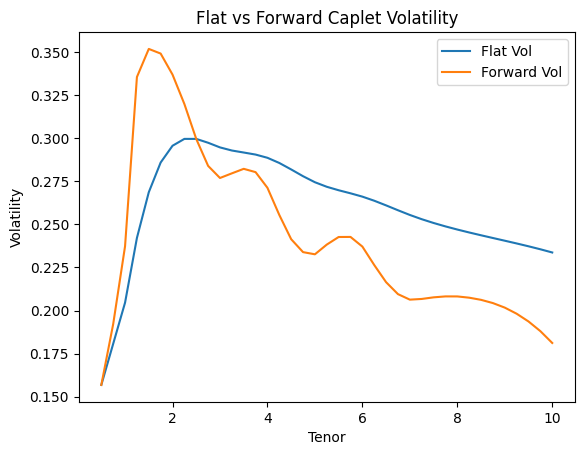

In [112]:
with_stripped_fwd_vol = strip_caps(full_df, strike)

import matplotlib.pyplot as plt

plt.plot(with_stripped_fwd_vol["tenor"], with_stripped_fwd_vol["flat vols"], label="Flat Vol")
plt.plot(with_stripped_fwd_vol["tenor"], with_stripped_fwd_vol["fwd_vol_stripped"], label="Forward Vol")
plt.legend()
plt.xlabel("Tenor")
plt.ylabel("Volatility")
plt.title("Flat vs Forward Caplet Volatility")
plt.show()